# 02 · Search spaces and the Optuna study

This tutorial covers everything about the `search_space` argument and the study it drives.

Chapter 2 of the book introduces `GridSearchCV` and `RandomizedSearchCV`. `mloptune`
uses Optuna's TPE sampler instead: it starts with random trials, then proposes new
combinations from the ones that scored well. You describe *ranges*, not grids.

In [1]:
import warnings

warnings.filterwarnings("ignore")  # hide convergence and progress-bar warnings in tutorial output

import optuna

optuna.logging.set_verbosity(optuna.logging.ERROR)  # Optuna otherwise logs every trial, and a traceback per failed one

In [2]:
import matplotlib.pyplot as plt

SERIES = ["#2a78d6", "#eb6834", "#1baf7a"]  # categorical palette, used in this fixed order
INK, INK_2, GRID = "#0b0b0b", "#52514e", "#e5e4e0"


def tidy(ax, title, xlabel, ylabel):
    """Recessive axes and grid so the data, not the frame, carries the chart."""
    ax.set_title(title, loc="left", color=INK, fontsize=12, pad=12)
    ax.set_xlabel(xlabel, color=INK_2)
    ax.set_ylabel(ylabel, color=INK_2)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID)
    ax.tick_params(colors=INK_2)
    ax.grid(axis="y", color=GRID, linewidth=1)
    ax.set_axisbelow(True)

## 1. The three spec types

| `type` | Required keys | Optional keys | Optuna call |
|---|---|---|---|
| `"int"` | `low`, `high` | `step` (default 1) | `suggest_int` |
| `"float"` | `low`, `high` | `step`, `log` (not both) | `suggest_float` |
| `"categorical"` | `choices` (non-empty list) | — | `suggest_categorical` |

Use `log=True` for hyperparameters that span orders of magnitude (learning rates,
regularization strengths): the book's advice to "try consecutive powers of 10" is what a
log-uniform range does continuously.

In [3]:
from sklearn.datasets import load_breast_cancer, make_classification

from mloptune import FineTuneConfig, FineTuner

# A synthetic problem with label noise, so there is genuinely something to tune.
X, y = make_classification(n_samples=1500, n_features=30, n_informative=8, n_redundant=6,
                           flip_y=0.08, class_sep=0.8, random_state=2)
cancer = load_breast_cancer()  # used further down

config = FineTuneConfig(
    model_name="HistGradientBoostingClassifier",
    problem_type="classification",
    experiment_name="tutorial-02-hgb",
    scoring="roc_auc",
    n_trials=20,
    search_space={
        "learning_rate": {"type": "float", "low": 0.01, "high": 0.5, "log": True},
        "max_leaf_nodes": {"type": "int", "low": 4, "high": 64, "step": 4},
        "l2_regularization": {"type": "float", "low": 0.0, "high": 2.0},
        "max_features": {"type": "categorical", "choices": [0.5, 0.75, 1.0]},
    },
    model_kwargs={"max_iter": 150},
)
result = FineTuner(config).run(X, y)
print("best:", result.best_params)
print("validation ROC AUC:", round(result.validation_score, 4), "| test ROC AUC:", round(result.test_score, 4))

best: {'learning_rate': 0.09383976152385703, 'max_leaf_nodes': 32, 'l2_regularization': 1.5564700850480113, 'max_features': 0.5}
validation ROC AUC: 0.8983 | test ROC AUC: 0.8949


## 2. Inspect the study

Every trial is in `result.study`. The dataframe view is the fastest way to see which
regions of the space scored well.

In [4]:
trials = result.study.trials_dataframe(attrs=("number", "value", "params", "state"))
trials.sort_values("value", ascending=False).head(8)

,number,value,params_l2_regularization,params_learning_rate,params_max_features,params_max_leaf_nodes,state
4,4,0.898267,1.556470,0.093840,0.50,32,COMPLETE
3,3,0.897156,1.571302,0.055223,0.75,16,COMPLETE
2,2,0.896178,0.402418,0.134188,0.50,36,COMPLETE
11,11,0.894978,1.833212,0.085058,0.75,28,COMPLETE
0,0,0.892578,0.732108,0.174959,0.50,40,COMPLETE
14,14,0.891067,1.032013,0.034757,0.75,28,COMPLETE
12,12,0.890533,1.621463,0.120292,0.50,16,COMPLETE
15,15,0.889644,1.408871,0.098872,0.75,36,COMPLETE


### Optimization history

Each dot is one trial's validation score; the line is the best score found so far.
The first ten dots are Optuna's random startup trials (next section); the remaining ten
are proposed by TPE. In this run the best score came from trial 4, a random one, and
none of the model-based trials beat it: twenty trials is a small budget for a
four-dimensional space, and TPE keeps exploring, which is why later dots still scatter.

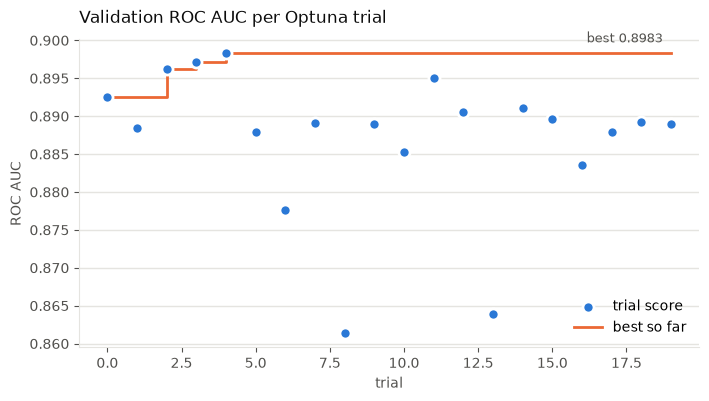

In [5]:
best_so_far = trials["value"].cummax()

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(trials["number"], trials["value"], s=64, color=SERIES[0], edgecolor="white", linewidth=2,
           label="trial score", zorder=3)
ax.step(trials["number"], best_so_far, where="post", color=SERIES[1], linewidth=2, label="best so far", zorder=2)
ax.annotate(f"best {best_so_far.iloc[-1]:.4f}", (trials["number"].iloc[-1], best_so_far.iloc[-1]),
            xytext=(-6, 8), textcoords="offset points", ha="right", color=INK_2, fontsize=9)
ax.legend(frameon=False, loc="lower right")
tidy(ax, "Validation ROC AUC per Optuna trial", "trial", "ROC AUC")
plt.show()

## 3. Random startup trials: read this before trusting "TPE"

Optuna's TPE sampler needs data before it can model the objective, so its first
`n_startup_trials` (**default 10**) are uniformly random. With the library's default
`n_trials=10` the whole study is therefore plain random search.

Two ways out: raise `n_trials`, or lower `n_startup_trials`. The run above used 20 trials,
so its second half was model-based. Below, the same budget with only 5 random trials.

In [6]:
import dataclasses

config_5 = dataclasses.replace(config, n_startup_trials=5)
result_5 = FineTuner(config_5).run(X, y)

print("default startup (10 random of 20): validation", round(result.validation_score, 4), "| test", round(result.test_score, 4))
print("n_startup_trials=5  (5 random of 20): validation", round(result_5.validation_score, 4), "| test", round(result_5.test_score, 4))

default startup (10 random of 20): validation 0.8983 | test 0.8949
n_startup_trials=5  (5 random of 20): validation 0.8983 | test 0.8949


The numbers coincide here because both studies share their first five random trials and
both found their best score at trial 4, so the extra model-based trials had nothing to add.
On larger spaces and budgets giving TPE more model-based trials matters. Either way, judge
by `test_score`, not by which validation score is higher.

## 4. `model_kwargs` versus `search_space`

`model_kwargs` are fixed; `search_space` entries are tuned. If a name appears in both,
the tuned value wins for that trial. Use `model_kwargs` for things that should never
change (`max_iter`, `n_jobs`, `class_weight`) and for `random_state` if you want to
override the experiment seed.

In [7]:
config_fixed = FineTuneConfig(
    model_name="RandomForestClassifier",
    problem_type="classification",
    experiment_name="tutorial-02-rf",
    n_trials=6,
    model_kwargs={"n_estimators": 100, "class_weight": "balanced", "n_jobs": -1},
    search_space={"max_depth": {"type": "int", "low": 2, "high": 12}},
)
rf = FineTuner(config_fixed).run(cancer.data, cancer.target)

params = rf.model.get_params()
print({k: params[k] for k in ("n_estimators", "class_weight", "max_depth", "random_state")})
print("random_state equals the experiment seed:", params["random_state"] == rf.seed)

{'n_estimators': 100, 'class_weight': 'balanced', 'max_depth': 9, 'random_state': 3835745450}
random_state equals the experiment seed: True


## 5. A failing trial does not kill the study

Some hyperparameter combinations are invalid for a given dataset. Optuna marks those
trials `FAIL` and moves on; the best *completed* trial wins. Here `kernel="precomputed"`
is a valid SVC option but cannot work on raw features. (At Optuna's default log level each
failed trial prints a warning with its traceback; the setup cell silenced that.)

In [8]:
config_svc = FineTuneConfig(
    model_name="SVC",
    problem_type="classification",
    experiment_name="tutorial-02-svc",
    n_trials=8,
    search_space={
        "kernel": {"type": "categorical", "choices": ["linear", "rbf", "precomputed"]},
        "C": {"type": "float", "low": 0.01, "high": 100, "log": True},
    },
)
svc = FineTuner(config_svc).run(cancer.data, cancer.target)

svc.study.trials_dataframe(attrs=("number", "state", "params", "value"))

,number,state,params_C,params_kernel,value
0,0,COMPLETE,0.037058,linear,0.938596
1,1,COMPLETE,0.647613,rbf,0.947368
2,2,COMPLETE,46.729289,linear,0.956140
3,3,FAIL,3.809004,precomputed,NaN
4,4,COMPLETE,0.011057,linear,0.947368
5,5,COMPLETE,0.010173,rbf,0.622807
6,6,COMPLETE,3.666167,rbf,0.938596
7,7,COMPLETE,5.371028,linear,0.956140


In [9]:
print("best (from completed trials only):", svc.best_params)

best (from completed trials only): {'kernel': 'linear', 'C': 46.729289489958994}


If *every* trial fails, `run` raises a `RuntimeError` that quotes the last error instead of
Optuna's generic "no trials are completed".

## 6. Mistakes are caught before any training starts

`FineTuneConfig` validates itself, and `FineTuner` checks the model name and every
hyperparameter name against the estimator's constructor. Each of these fails in
milliseconds, not after a long study.

In [10]:
bad_configs = {
    "typo in hyperparameter name": dict(search_space={"n_estimator": {"type": "int", "low": 5, "high": 10}}),
    "low > high": dict(search_space={"max_depth": {"type": "int", "low": 8, "high": 2}}),
    "step combined with log": dict(search_space={"ccp_alpha": {"type": "float", "low": 0.1, "high": 10, "log": True, "step": 0.5}}),
    "unknown spec type": dict(search_space={"max_depth": {"type": "uniform", "low": 1, "high": 8}}),
    "regressor for classification": dict(model_name="RandomForestRegressor"),
    "not a predictor at all": dict(model_name="PCA"),
    "n_trials=0 with a search space": dict(n_trials=0, search_space={"max_depth": {"type": "int", "low": 1, "high": 4}}),
    "splits add up to >= 1": dict(test_size=0.5, validation_size=0.5),
}

base = dict(model_name="RandomForestClassifier", problem_type="classification", experiment_name="bad")
for label, overrides in bad_configs.items():
    try:
        FineTuner(FineTuneConfig(**{**base, **overrides}))
    except ValueError as exc:
        print(f"{label:32s} -> {str(exc)[:90]}")

typo in hyperparameter name      -> RandomForestClassifier has no hyperparameter(s) ['n_estimator']; valid names include ['boo
low > high                       -> search_space['max_depth']: 'low' must not exceed 'high'.
step combined with log           -> search_space['ccp_alpha']: 'step' cannot be combined with log=True.
unknown spec type                -> search_space['max_depth'] has unsupported type 'uniform'; expected one of ('int', 'float',
regressor for classification     -> RandomForestRegressor is a regressor, but problem_type is 'classification'.
not a predictor at all           -> Unknown model_name: PCA. It must be a scikit-learn classifier (see sklearn.utils.all_estim
n_trials=0 with a search space   -> n_trials must be at least 1 when a search_space is given.
splits add up to >= 1            -> test_size + validation_size must be less than 1.


## Takeaways

- Describe ranges, prefer `log=True` for scale-like hyperparameters.
- Read `study.trials_dataframe()`; the best score alone hides how flat or noisy the landscape is.
- Give TPE room: more than 10 trials, or a smaller `n_startup_trials`.
- Invalid combinations cost one failed trial, not the study; invalid configs cost nothing.